# Bayesian Economic Order Quantity (EOQ)

This tutorial implements a Bayesian EOQ. The model uses traditional economic order quantity with its parameters (demand, order cost, holding cost) being a probability distribution.

Key Features:
- Generates the probability distribution of the parameters from empirical data and subjective priors
- Generates the probability distribution and confidence interval of the EOQ

The Bayesian Economic Order Quantity provides:
- Credible interval for the EOQ
- Most probable value for the EOQ, given the empirical and prior parameters

Library Dependencies:
- numpy: Numerical computations
- matplotlib: Visualize plots

In [1]:
from supplyseer.bayesian.bayesian_eoq import (
    BayesianEOQConfig,
    BayesianEOQ,
    ProbabilityDistributionConfig,
    ProbabilityDistribution,
    SimulationConfig,
)

### Leveraging Probability Distribution for Demand / Order Cost / Holding Cost

The main feature of Bayesian statistics is that we can incorporate our prior knowledge to make our result more contextual.

We will demonstrate this feature to calculate the **Demand** of item based three scenarios, leveraging example from `eoq.ipynb`:
1. Item `X` just running business as usual
2. Item `Y` is a seasonal item and the empirical demand is based on the high season
3. Item `Z` is a new item and we don't have complete empirical demand

#### 1. Demand of item `X` just running business as usual

In [2]:
# Simulation parameters
N_POINTS = 100  # number of discretization points for the demand distribution

In [3]:
# Demand distribution parameters
X_D_EMPIRICAL = 100  # empirical demand
X_D_INITIAL = 100  # initial demand, there is no reason to differentiate between empirical and initial demand
X_D_MIN = 50  # minimum demand
X_D_MAX = 250  # maximum demand

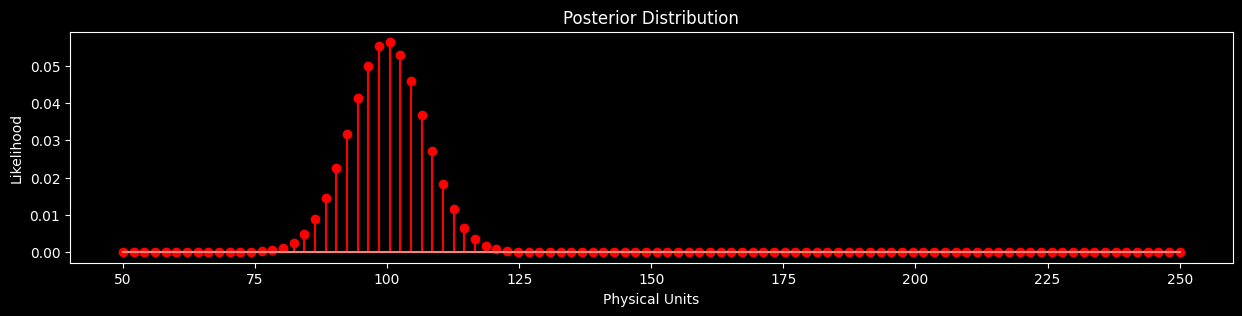

In [4]:
# Demand distribution
x_d_config = ProbabilityDistributionConfig(
    empirical=X_D_EMPIRICAL,
    prior=X_D_INITIAL,
    min=X_D_MIN,
    max=X_D_MAX,
    num_points=N_POINTS,
)
x_d = ProbabilityDistribution(x_d_config)
x_d.plot_posterior()

**Highlights**

We introduce variability for the demand of `X`. Thus, we can determine the credible interval for the order quantity later

#### 2. Demand of item `Y` is a seasonal item and the empirical demand is based on the high season

In [5]:
# Simulation parameters
N_POINTS = 100  # number of discretization points for the demand distribution

In [6]:
# Demand distribution parameters
Y_D_EMPIRICAL = 200  # empirical demand
Y_D_INITIAL = 100  # initial demand, our prior demand is lower than the empirical demand due to high season
Y_D_MIN = 50  # minimum demand
Y_D_MAX = 250  # maximum demand

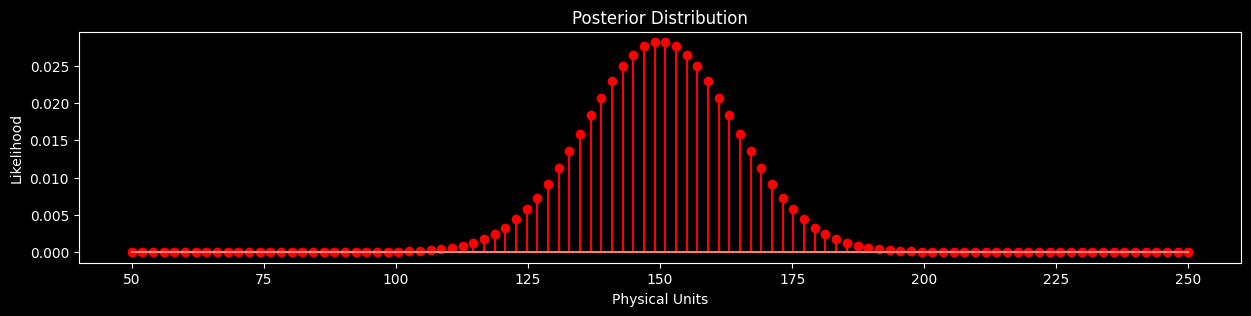

In [7]:
# Demand distribution
y_d_config = ProbabilityDistributionConfig(
    empirical=Y_D_EMPIRICAL,
    prior=Y_D_INITIAL,
    min=Y_D_MIN,
    max=Y_D_MAX,
    num_points=N_POINTS,
)
y_d = ProbabilityDistribution(y_d_config)
y_d.plot_posterior()

**Highlights**

Since the prior and empirical demand of item `Y` are different, it resulted in larger spread of the distribution (i.e., more uncertainty)

#### 3. Demand of item `Z` is a new item and we don't have complete empirical demand

In [8]:
# Simulation parameters
N_POINTS = 100  # number of discretization points for the demand distribution

In [9]:
# Demand distribution parameters
Z_D_EMPIRICAL = 30  # empirical demand
Z_D_INITIAL = 100  # initial demand, our prior demand is higher than the empirical demand due to incomplete empirical data
Z_D_MIN = 50  # minimum demand
Z_D_MAX = 250  # maximum demand
Z_D_COV = 0.5  # coefficient of variation is set higher due to incomplete empirical data

/Users/yusufprasetyo/Documents/repo/supplyseer/supplyseer/bayesian/bayesian_eoq.py:54: Warning: empirical value not within min and max range, distribution may be truncated
  warnings.warn(msg, Warning)


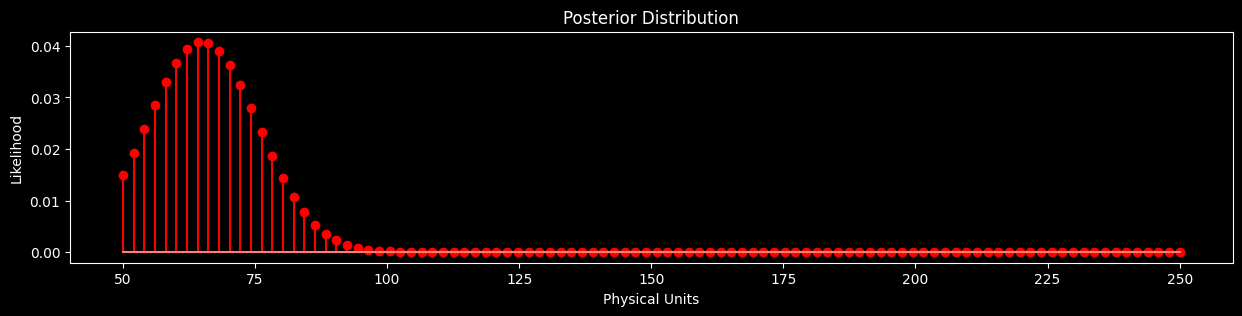

In [10]:
# Demand distribution
z_d_config = ProbabilityDistributionConfig(
    empirical=Z_D_EMPIRICAL,
    prior=Z_D_INITIAL,
    min=Z_D_MIN,
    max=Z_D_MAX,
    num_points=N_POINTS,
    coefficient_of_variance=Z_D_COV,
)
z_d = ProbabilityDistribution(z_d_config)
z_d.plot_posterior()

**Highlights**

There was a warning to ensure that we acknowledge demand for item `Z` are not supposed to be as low as empirically recorded.

We put the lower bound based on our prior minimum value while incorporating the information from our empirical demand.

### Determining Economic Order Quantity from Probability Distribution of Demand

Now we are going to calculate the economic order quantity of previous items based on their demand

In [11]:
# Initializing Order Cost
A_EMPIRICAL = 100  # empirical order cost
A_INITIAL = 100  # initial order cost, no reason to differentiate between empirical and initial order cost
A_MIN = 80  # minimum order cost
A_MAX = 140  # maximum order cost, suppose that the political situation is unstable and prices are volatile

# Initializing Holding Cost
H_EMPIRICAL = 0.02  # empirical holding cost
H_INITIAL = 0.02  # initial holding cost, no reason to differentiate between empirical and initial holding cost
H_MIN = 0.018  # minimum holding cost
H_MAX = 0.03  # maximum holding cost, suppose that the inflation rate is volatile

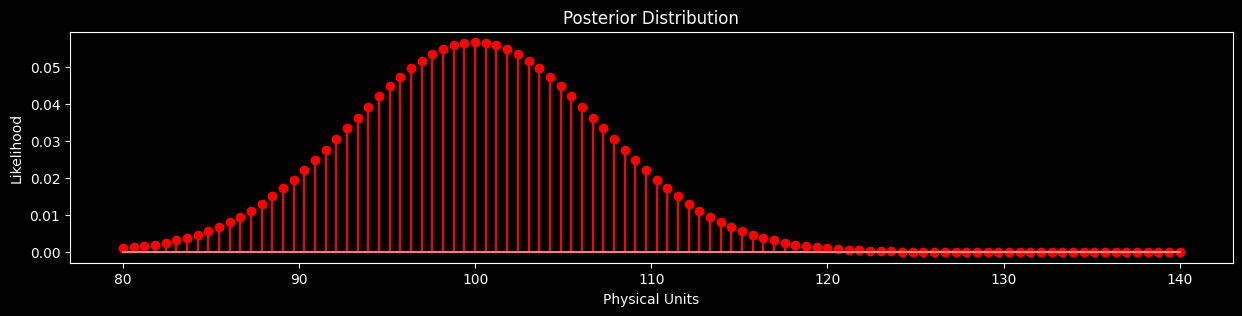

In [12]:
# Order Cost distribution
a_config = ProbabilityDistributionConfig(
    empirical=A_EMPIRICAL,
    prior=A_INITIAL,
    min=A_MIN,
    max=A_MAX,
    num_points=N_POINTS,
)
a = ProbabilityDistribution(a_config)
a.plot_posterior()

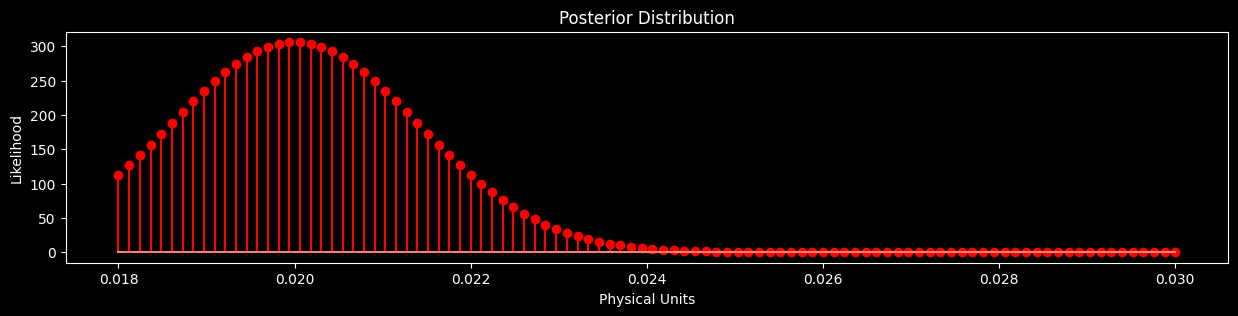

In [13]:
# Order Cost distribution
h_config = ProbabilityDistributionConfig(
    empirical=H_EMPIRICAL,
    prior=H_INITIAL,
    min=H_MIN,
    max=H_MAX,
    num_points=N_POINTS,
)
h = ProbabilityDistribution(h_config)
h.plot_posterior()

In [14]:
simulation_config = SimulationConfig()

In [15]:
x_bayesian_eoq_config = BayesianEOQConfig(
    demand=x_d,
    order_cost=a,
    holding_cost=h,
    simulation_config=simulation_config,
)
x_bayesian_eoq = BayesianEOQ(x_bayesian_eoq_config)

In [16]:
x_bayesian_eoq.get_most_probable_values()

{'eoq': 1001.0065427812327,
 'd': 100.5050505050505,
 'a': 100.0,
 'h': 0.02006060606060606}

In [17]:
sorted(x_bayesian_eoq.calculate_credible_interval())

[827.5830737496269,
 977.929206394961,
 1014.0945981889103,
 1198.3240801712263,
 1281.8230039030268,
 1514.6904192544298,
 1570.706102292281,
 1856.0546014249671]

Note that there were 3 variables for the lower and upper bound of the credible interval, hence `2^3 = 8` points.

In [18]:
x_bayesian_eoq.get_least_probable_values()

{'min': {'eoq': 516.3977794943223, 'd': 50.0, 'a': 80.0, 'h': 0.03},
 'max': {'eoq': 1972.0265943665388, 'd': 250.0, 'a': 140.0, 'h': 0.018}}

For item `X`, we found that:
* The most probable value of the economic order quantity is 1001 unit
* Most probable demand value is 100 unit
* The credible interval for the economic order quantity is between 827 to 1856
* The span for economic order quantity is between 516 (min) and 1972 (max)

In [19]:
y_bayesian_eoq_config = BayesianEOQConfig(
    demand=y_d,
    order_cost=a,
    holding_cost=h,
    simulation_config=simulation_config,
)
y_bayesian_eoq = BayesianEOQ(y_bayesian_eoq_config)

In [20]:
y_bayesian_eoq.get_most_probable_values()

{'eoq': 1218.7689627207612,
 'd': 148.989898989899,
 'a': 100.0,
 'h': 0.02006060606060606}

In [21]:
sorted(y_bayesian_eoq.calculate_credible_interval())

[589.4978059246229,
 696.5912423842598,
 722.3523046741676,
 853.5812759521149,
 990.8549313758217,
 1170.8624879223223,
 1214.16286215764,
 1434.7385318603979]

In [22]:
y_bayesian_eoq.get_least_probable_values()

{'min': {'eoq': 516.3977794943223, 'd': 50.0, 'a': 80.0, 'h': 0.03},
 'max': {'eoq': 1972.0265943665388, 'd': 250.0, 'a': 140.0, 'h': 0.018}}

For item `Y`, we found that:
* The most probable value of the economic order quantity is 1218 unit
* Most probable demand value is 148 unit
* The credible interval for the economic order quantity is between 589 to 1439
* The span for economic order quantity is between 589 (min) and 1434 (max)

In [23]:
z_bayesian_eoq_config = BayesianEOQConfig(
    demand=z_d,
    order_cost=a,
    holding_cost=h,
    simulation_config=simulation_config,
)
z_bayesian_eoq = BayesianEOQ(z_bayesian_eoq_config)

In [24]:
z_bayesian_eoq.get_most_probable_values()

{'eoq': 799.6726419856957,
 'd': 64.14141414141415,
 'a': 100.0,
 'h': 0.02006060606060606}

In [25]:
sorted(z_bayesian_eoq.calculate_credible_interval())

[644.1932003237317,
 761.2230906358615,
 789.3743424191406,
 932.7791356738612,
 1281.8230039030268,
 1514.6904192544298,
 1570.706102292281,
 1856.0546014249671]

In [26]:
z_bayesian_eoq.get_least_probable_values()

{'min': {'eoq': 516.3977794943223, 'd': 50.0, 'a': 80.0, 'h': 0.03},
 'max': {'eoq': 1972.0265943665388, 'd': 250.0, 'a': 140.0, 'h': 0.018}}

For item `Z`, we found that:
* The most probable value of the economic order quantity is 799 unit
* Most probable demand value is 64 unit
* The credible interval for the economic order quantity is between 644 to 1856
* The span for economic order quantity is between 516 (min) and 1972 (max)

We can see that the least probable values are the same because it is determined solely from the prior span.

Thus, in practical settings, it is better to use credible interval instead.

We can also leverage `compute_full_analysis()` for exploration. Below is example for item `X`

In [27]:
x_bayesian_eoq.compute_full_analysis()

{'bayesian_eoq_most_probable': {'eoq': 1001.0065427812327,
  'd': 100.5050505050505,
  'a': 100.0,
  'h': 0.02006060606060606},
 'bayesian_eoq_min_least_probable': {'eoq': 516.3977794943223,
  'd': 50.0,
  'a': 80.0,
  'h': 0.03},
 'bayesian_eoq_max_least_probable': {'eoq': 1972.0265943665388,
  'd': 250.0,
  'a': 140.0,
  'h': 0.018},
 'eoq_distribution': [666.6666666666667,
  664.433271221689,
  662.22217267324,
  660.0330024752063,
  657.8654005538684,
  655.7190150591165,
  653.5935021245373,
  651.4885256360006,
  649.403757008391,
  647.3388749701497,
  645.2935653553033,
  643.267520902677,
  641.2604410619979,
  639.2720318066127,
  637.3020054525532,
  635.3500804836985,
  633.4159813827913,
  631.4994384680786,
  629.6001877353567,
  627.7179707052114,
  625.8525342752506,
  624.0036305771397,
  622.1710168382551,
  620.3544552477822,
  618.5537128270867,
  616.7685613042031,
  614.9987769922845,
  613.2441406718666,
  611.5044374768056,
  609.7794567837564,
  608.06899210506

In [28]:
x_bayesian_eoq.compute_full_analysis().keys()

dict_keys(['bayesian_eoq_most_probable', 'bayesian_eoq_min_least_probable', 'bayesian_eoq_max_least_probable', 'eoq_distribution', 'eoq_credible_interval'])